Here we are going to use out Data to Develop a Model that will take two images as input and tell us how similar they are.

In [12]:
# Makes Tensorflow showing less erros messages.
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Imports
import numpy as np
import tensorflow as tf
import cv2
import matplotlib.pyplot as plt
import random
from tensorflow import keras
from tensorflow.keras import layers
from itertools import combinations

In [13]:
print(tf.__version__)

2.6.0


## Importing Images and Data set Preparation

In [14]:
# Lists all the file names from the Source folder
base_path = 'data/train/palm_images_resized/'

files = os.listdir(base_path)
files = [file for file in files if file[-1] != '~']

print(len(files))

16


In [15]:
# Getting all the images in RGB formats and storing them all in a container array
classes = ['Vighnesh S.', 'Sai Nilayam Sahu', 'Vanshi', 'Yogesh', 'Norottam', 'Pratyush', 'Gopi', 'Abhay Kumar Singh']

X = []
y = []

for file in files:
    # Creating the File path (Image Path).
    file_path = base_path + file
    # Opening the Image using OpenCV
    inst_img = cv2.imread(file_path)
    # Converting the img to a Numpy Array
    inst_img_arr = np.array(inst_img)
    # Adding the Image Array to the Container Array. 
    X.append(inst_img_arr)
    
    # The other thing is to use grab the label from the Image name.
    inst_label = int(file[0])
    # Append the label to the 'y' Array.
    y.append(inst_label)
    
# Converting both X and y to Numpy Arrays for Efficient Computaion.
X = np.array(X)
y = np.array(y).reshape(len(X), -1)

print('Shape of X: ', X.shape)
print('Shape of y: ', y.shape)

Shape of X:  (16, 128, 64, 3)
Shape of y:  (16, 1)


Shape of the Image:  (128, 64, 3)


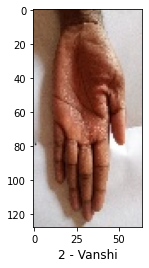

In [16]:
# Let's show one of the Image from our X Array.
index = 11

img = X[index]
# Converting BGR to RGB 
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

label = y[index][0]
class_ = classes[label]

print('Shape of the Image: ', img.shape)

plt.imshow(img)
plt.xlabel('{} - {}'.format(label, class_), size=12)
plt.show()

###### 

In [17]:
# Now the objective is to make the Training set for our Siamese Network.

# Making the big X_y Tensor.
X_y = []
for i in range(len(X)):
    inst_arr = []
    inst_X = X[i]
    inst_y = y[i]
    inst_arr.append(inst_X)
    inst_arr.append(inst_y)
    
    X_y.append(inst_arr)
    
print(len(X_y))

16


In [18]:
# Now we will build X pairs and y label such that if the class of X pair is same the y label will be 1 and if the 
# class of X pairs is not same, y label is going to be 0.

# Creating index pairs to create combinations
all_combinations = combinations(range(16), 2)

all_combinations_list = [combination for combination in all_combinations]
    
# Appending some extra elements
extra_elements = [(i, i) for i in range(16)]
for ele in extra_elements:
    all_combinations_list.append(ele)

all_combinations = all_combinations_list

# Randomizing all_combinations with a Random seed 4.
random.Random(4).shuffle(all_combinations)
    
print(all_combinations, end='\n\n')
print(len(all_combinations))

[(9, 9), (1, 5), (0, 9), (3, 7), (11, 13), (7, 14), (0, 0), (4, 7), (3, 12), (6, 7), (1, 3), (6, 13), (7, 10), (12, 15), (6, 10), (2, 6), (5, 13), (1, 6), (1, 12), (4, 13), (10, 13), (0, 3), (3, 4), (5, 15), (0, 2), (1, 1), (4, 10), (3, 15), (4, 14), (7, 13), (4, 9), (1, 2), (5, 12), (0, 15), (10, 14), (0, 7), (5, 8), (3, 10), (7, 8), (5, 10), (6, 11), (10, 15), (7, 11), (6, 15), (7, 15), (14, 15), (8, 12), (4, 12), (6, 6), (13, 13), (0, 5), (0, 13), (8, 9), (0, 10), (9, 11), (3, 6), (2, 4), (2, 15), (11, 14), (13, 15), (8, 8), (2, 14), (4, 4), (6, 8), (0, 11), (7, 7), (9, 15), (8, 13), (2, 3), (1, 7), (4, 8), (4, 6), (2, 10), (4, 5), (3, 14), (12, 12), (5, 6), (12, 13), (5, 14), (8, 15), (0, 1), (2, 12), (5, 5), (8, 11), (12, 14), (15, 15), (7, 12), (11, 15), (2, 5), (4, 15), (3, 11), (7, 9), (3, 5), (14, 14), (0, 12), (3, 9), (8, 10), (6, 12), (3, 3), (10, 10), (1, 8), (1, 11), (2, 8), (11, 11), (11, 12), (9, 14), (6, 14), (10, 12), (0, 4), (1, 14), (2, 7), (0, 14), (10, 11), (1, 9),

In [19]:
# Now we could do have 136 Training examples

X_1 = []
X_2 = []
y_similarity = []

for combination in all_combinations:
    x_1, x_2 = combination
    
    inst_img_1 = X[x_1]
    inst_img_2 = X[x_2]
    
    X_1.append(inst_img_1)
    X_2.append(inst_img_2)
    
    inst_y_1 = y[x_1][0]
    inst_y_2 = y[x_2][0]
    
    if inst_y_1 == inst_y_2:
        similarity = 1
    else:
        similarity = 0
    y_similarity.append(similarity)
    
X_1 = np.array(X_1)
X_2 = np.array(X_2)

y_similarity = np.array(y_similarity)
y_similarity = y_similarity.reshape(136, -1)
    
print(X_1.shape)
print(X_2.shape)
print(y_similarity.shape)

(136, 128, 64, 3)
(136, 128, 64, 3)
(136, 1)


Shape of the Image:  (128, 64, 3)


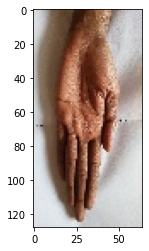

Shape of the Image:  (128, 64, 3)


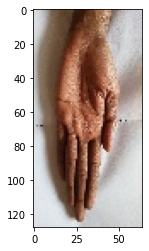

1


In [20]:
# Testing our Training set.
index = 6

img_1 = X_1[index]
img_2 = X_2[index]
# Converting BGR to RGB 
img_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
img_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)

similarity = y_similarity[index][0]

print('Shape of the Image: ', img.shape)
plt.imshow(img_1)
plt.show()

print('Shape of the Image: ', img.shape)
plt.imshow(img_2)
plt.show()

print(similarity)

## Building a Siamese Network
In this problem we are going to use a Siamese Network Architecture. This includes Convolutional Layers, Average Pooling Layers, Flatten Layer, Dense Layer, a Custom Layer.

Model: "model_2"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_layer (InputLayer)     [(None, 128, 64, 3)]      0         
_________________________________________________________________
conv_layer_1 (Conv2D)        (None, 128, 64, 8)        224       
_________________________________________________________________
batch_normalization_1 (Batch (None, 128, 64, 8)        32        
_________________________________________________________________
average_pooling_layer_1 (Ave (None, 64, 32, 8)         0         
_________________________________________________________________
flatten_layer_1 (Flatten)    (None, 16384)             0         
_________________________________________________________________
dense_layer_3 (Dense)        (None, 512)               8389120   
Total params: 8,389,376
Trainable params: 8,389,360
Non-trainable params: 16
________________________________________________

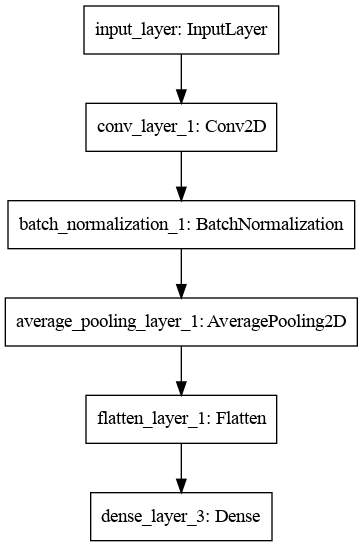

In [42]:
# Building the Base Embedding Network

input_layer = tf.keras.layers.Input(shape=(128, 64, 3), name='input_layer')

x = tf.keras.layers.Conv2D(8, 3, strides=(1,1), padding='same', activation=tf.nn.sigmoid, name='conv_layer_1')(input_layer)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.AveragePooling2D(pool_size=(2, 2), name='average_pooling_layer_1')(x)

x = tf.keras.layers.Flatten(name='flatten_layer_1')(x)

output_layer = tf.keras.layers.Dense(512, activation=tf.nn.sigmoid, name='dense_layer_3')(x)

embedding_network = tf.keras.Model(inputs=input_layer, outputs=output_layer)

embedding_network.summary()
tf.keras.utils.plot_model(embedding_network)

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_layer_for_img_1 (InputLay [(None, 128, 64, 3)] 0                                            
__________________________________________________________________________________________________
input_layer_for_img_2 (InputLay [(None, 128, 64, 3)] 0                                            
__________________________________________________________________________________________________
model_2 (Functional)            (None, 512)          8389376     input_layer_for_img_1[0][0]      
                                                                 input_layer_for_img_2[0][0]      
__________________________________________________________________________________________________
lambda_1 (Lambda)               (None, 1)            0           model_2[0][0]              

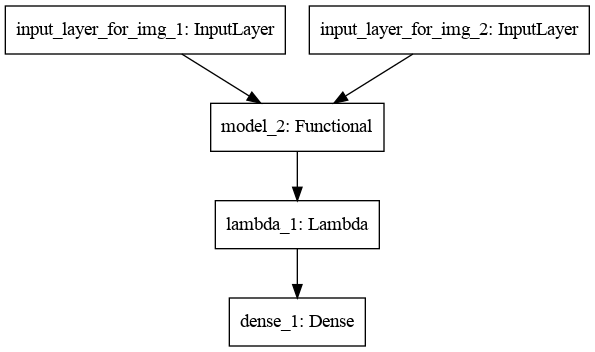

In [43]:
# Building the Siamese Network.

input_layer_1 = tf.keras.layers.Input(shape=(128, 64, 3), name='input_layer_for_img_1')
input_layer_2 = tf.keras.layers.Input(shape=(128, 64, 3), name='input_layer_for_img_2')

embedding_network_1 = embedding_network(input_layer_1)
embedding_network_2 = embedding_network(input_layer_2)

def euclidean_distance(tensor_list):
    x = tensor_list[0]
    y = tensor_list[1]
    sum_of_squres = tf.math.reduce_sum(tf.math.square(x - y), axis=1, keepdims=True)
    return sum_of_squres

merge_layer = tf.keras.layers.Lambda(euclidean_distance)([embedding_network_1, embedding_network_2])
similarity = tf.keras.layers.Dense(1, activation=tf.nn.sigmoid)(merge_layer)

siamese_network = tf.keras.Model(inputs=[input_layer_1, input_layer_2], outputs=similarity)

siamese_network.summary()
tf.keras.utils.plot_model(siamese_network)

In [72]:
# Importing the Pre-Trained Model.
siamese_network = tf.keras.models.load_model('models/model_1/')

siamese_network.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_layer_for_img_1 (InputLay [(None, 128, 64, 3)] 0                                            
__________________________________________________________________________________________________
input_layer_for_img_2 (InputLay [(None, 128, 64, 3)] 0                                            
__________________________________________________________________________________________________
model_2 (Functional)            (None, 512)          8389376     input_layer_for_img_1[0][0]      
                                                                 input_layer_for_img_2[0][0]      
__________________________________________________________________________________________________
lambda_1 (Lambda)               (None, 1)            0           model_2[0][0]              

In [73]:
# Definging the 'Cost Function', 'Optimizer' and 'Evaluation Metrics' for the Model.
siamese_network.compile(
    loss=keras.losses.BinaryCrossentropy(),
    optimizer = keras.optimizers.Adam(learning_rate=0.007),
    metrics=['accuracy']
)

In [76]:
# Training the Model.
siamese_network.fit([X_1, X_2], y_similarity, batch_size=len(X_1), epochs=256, verbose=2)

Epoch 1/256
1/1 - 0s - loss: 0.0341 - accuracy: 1.0000
Epoch 2/256
1/1 - 0s - loss: 0.0339 - accuracy: 1.0000
Epoch 3/256
1/1 - 0s - loss: 0.0337 - accuracy: 1.0000
Epoch 4/256
1/1 - 0s - loss: 0.0334 - accuracy: 1.0000
Epoch 5/256
1/1 - 0s - loss: 0.0332 - accuracy: 1.0000
Epoch 6/256
1/1 - 0s - loss: 0.0329 - accuracy: 1.0000
Epoch 7/256
1/1 - 0s - loss: 0.0327 - accuracy: 1.0000
Epoch 8/256
1/1 - 0s - loss: 0.0325 - accuracy: 1.0000
Epoch 9/256
1/1 - 0s - loss: 0.0322 - accuracy: 1.0000
Epoch 10/256
1/1 - 0s - loss: 0.0320 - accuracy: 1.0000
Epoch 11/256
1/1 - 0s - loss: 0.0318 - accuracy: 1.0000
Epoch 12/256
1/1 - 0s - loss: 0.0315 - accuracy: 1.0000
Epoch 13/256
1/1 - 0s - loss: 0.0313 - accuracy: 1.0000
Epoch 14/256
1/1 - 0s - loss: 0.0311 - accuracy: 1.0000
Epoch 15/256
1/1 - 0s - loss: 0.0309 - accuracy: 1.0000
Epoch 16/256
1/1 - 0s - loss: 0.0307 - accuracy: 1.0000
Epoch 17/256
1/1 - 0s - loss: 0.0304 - accuracy: 1.0000
Epoch 18/256
1/1 - 0s - loss: 0.0302 - accuracy: 1.0000
E

Epoch 147/256
1/1 - 0s - loss: 0.0143 - accuracy: 1.0000
Epoch 148/256
1/1 - 0s - loss: 0.0142 - accuracy: 1.0000
Epoch 149/256
1/1 - 0s - loss: 0.0142 - accuracy: 1.0000
Epoch 150/256
1/1 - 0s - loss: 0.0141 - accuracy: 1.0000
Epoch 151/256
1/1 - 0s - loss: 0.0140 - accuracy: 1.0000
Epoch 152/256
1/1 - 0s - loss: 0.0140 - accuracy: 1.0000
Epoch 153/256
1/1 - 0s - loss: 0.0139 - accuracy: 1.0000
Epoch 154/256
1/1 - 0s - loss: 0.0138 - accuracy: 1.0000
Epoch 155/256
1/1 - 0s - loss: 0.0138 - accuracy: 1.0000
Epoch 156/256
1/1 - 0s - loss: 0.0137 - accuracy: 1.0000
Epoch 157/256
1/1 - 1s - loss: 0.0136 - accuracy: 1.0000
Epoch 158/256
1/1 - 0s - loss: 0.0136 - accuracy: 1.0000
Epoch 159/256
1/1 - 0s - loss: 0.0135 - accuracy: 1.0000
Epoch 160/256
1/1 - 0s - loss: 0.0134 - accuracy: 1.0000
Epoch 161/256
1/1 - 0s - loss: 0.0134 - accuracy: 1.0000
Epoch 162/256
1/1 - 0s - loss: 0.0133 - accuracy: 1.0000
Epoch 163/256
1/1 - 0s - loss: 0.0133 - accuracy: 1.0000
Epoch 164/256
1/1 - 0s - loss: 

In [77]:
# Saving the Model. Once we get a good model then only we save the model using the following codes. 
# siamese_network.save('models/model_1/')

INFO:tensorflow:Assets written to: models/model_1/assets


## Model Building Completed
From the Evaluation of the model using just he Train set itself, our model got an accuracy of 100%. This is awesome. Due to lack of Data we don't have a Dev set right now. 

## Model Testing

In [78]:
# Importing the Model.
model_test = tf.keras.models.load_model('models/model_1/')

model_test.summary()

Model: "model_3"
__________________________________________________________________________________________________
Layer (type)                    Output Shape         Param #     Connected to                     
input_layer_for_img_1 (InputLay [(None, 128, 64, 3)] 0                                            
__________________________________________________________________________________________________
input_layer_for_img_2 (InputLay [(None, 128, 64, 3)] 0                                            
__________________________________________________________________________________________________
model_2 (Functional)            (None, 512)          8389376     input_layer_for_img_1[0][0]      
                                                                 input_layer_for_img_2[0][0]      
__________________________________________________________________________________________________
lambda_1 (Lambda)               (None, 1)            0           model_2[0][0]              

In [91]:
# Creating testing Data pairs
img_1 = cv2.imread('data/test/palm_images_resized/vamshi_1.jpg')
img_1 = np.array(img_1)

img_2 = cv2.imread('data/test/palm_images_resized/sai_1.jpg')
img_2 = np.array(img_2)

X_1_test = [img_1]
X_2_test = [img_2]

X_1_test = np.array(X_1_test)
X_2_test = np.array(X_2_test)

print(X_1_test.shape)
print(X_2_test.shape)


(1, 128, 64, 3)
(1, 128, 64, 3)


Shape of the Image:  (128, 64, 3)


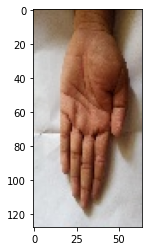

Shape of the Image:  (128, 64, 3)


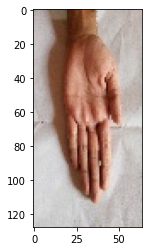

In [92]:
# Testing our Training set.

# Converting BGR to RGB 
img_1 = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
img_2 = cv2.cvtColor(img_2, cv2.COLOR_BGR2RGB)

print('Shape of the Image: ', img_1.shape)
plt.imshow(img_1)
plt.show()

print('Shape of the Image: ', img_2.shape)
plt.imshow(img_2)
plt.show()


In [93]:
prediction = model_test.predict([X_1_test, X_2_test])[0][0]
print('Similarity between two Images:', prediction)

# We have highly trained the Network up to the Minimum Loss Possilbe by the Network. We can't go below this as 
# because of Bias Problem. In this way for different Plams model says it in order of 10**-10 where as for same Palms
# it says more that 0.1. So we have set the threshold to 0.1. For different Plams the Prediction is going to be very
# very much tends to 0.

if prediction > 0.5:
    print('1')
    print('Two Palms are of Same.')
else:
    print('0')
    print('Tow Palms are not Same.')

Similarity between two Images: 0.021576583
0
Tow Palms are not Same.
